In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ushape.csv')

In [3]:
df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [5]:
df['X'] = df['3.159499363321345566e-02'] 
df['Y'] = df['9.869877579082642072e-01']
df['class'] = df['0.000000000000000000e+00']

In [6]:
df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00,X,Y,class
0,2.115098,-0.046244,1.0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0,2.112857,0.662084,1.0


In [8]:
df.drop(columns=['3.159499363321345566e-02','9.869877579082642072e-01','0.000000000000000000e+00'],inplace=True)

In [9]:
df.head()

,X,Y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [13]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values # this means only the values not the table structure

In [11]:
df.iloc[:,0:2]

,X,Y
0,2.115098,-0.046244
1,0.882490,-0.075756
2,-0.055144,-0.037332
3,0.829545,-0.539321
4,2.112857,0.662084
...,...,...
94,1.699453,0.587720
95,0.218623,-0.652521
96,0.952914,-0.419766
97,-1.318500,0.423112


In [12]:
df.iloc[:,0:2].values

array([[ 2.11509784, -0.04624397],
       [ 0.88248972, -0.07575606],
       [-0.0551441 , -0.03733246],
       [ 0.82954503, -0.53932149],
       [ 2.11285708,  0.66208353],
       [ 0.5696927 ,  0.33744136],
       [ 0.95217454, -0.75307471],
       [-0.02922115,  0.39287336],
       [ 1.71579557,  0.36069454],
       [-0.27883014,  0.61420539],
       [ 2.00344509, -0.3091496 ],
       [ 1.50009616, -0.74636376],
       [ 1.22540835,  1.19793017],
       [ 0.46730819,  0.54703192],
       [-0.36653222,  1.11971633],
       [ 0.30124459,  1.23315697],
       [ 0.30430746,  0.82373935],
       [-0.23712492,  0.77876034],
       [ 1.16339832,  0.55290238],
       [-0.59702417,  0.6572361 ],
       [ 0.46356735, -0.1951543 ],
       [ 0.68451111,  0.75287685],
       [ 0.70515699, -0.45892444],
       [-0.65805008, -0.12944211],
       [-0.74662946, -0.3829632 ],
       [ 0.60585226,  0.31252842],
       [ 2.18137168, -0.02291747],
       [ 1.91980633,  0.17247329],
       [ 1.4834364 ,

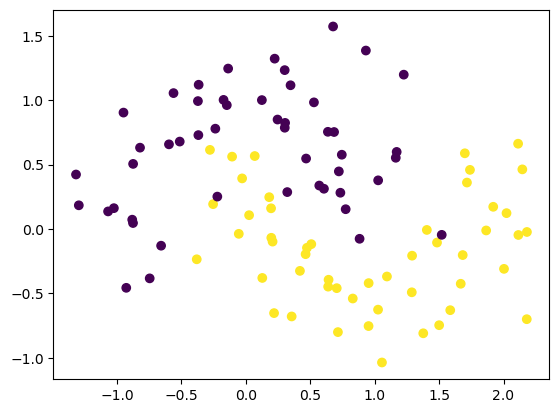

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y)

In [17]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [18]:
clf.fit(X,y)

LogisticRegression()

<Axes: >

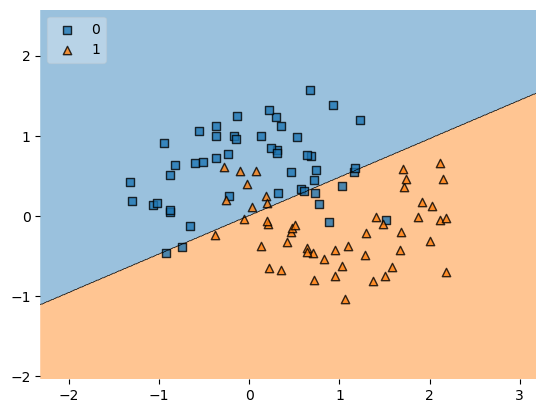

In [20]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X, y.astype('int'), clf, legend=2) # normal logistic regression will draw a line and try to differentiate the data

In [21]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(clf,X,y,scoring='accuracy',cv=10))

np.float64(0.8300000000000001)

In [22]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3,include_bias=False)
X_trf = poly.fit_transform(X)

In [23]:
clf1 = LogisticRegression()
np.mean(cross_val_score(clf1,X_trf,y,scoring='accuracy',cv=10))

np.float64(0.9099999999999999)

In [24]:
def plot_decision_boundary(X,y,degree=1):
    
    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)
    
    clf = LogisticRegression()
    clf.fit(X_trf,y)
    
    accuracy = np.mean(cross_val_score(clf,X_trf,y,scoring='accuracy',cv=10))
    
    a=np.arange(start=X[:,0].min()-1, stop=X[:,0].max()+1, step=0.01)
    b=np.arange(start=X[:,1].min()-1, stop=X[:,1].max()+1, step=0.01)


    XX,YY=np.meshgrid(a,b)
    
    input_array=np.array([XX.ravel(),YY.ravel()]).T

    labels=clf.predict(poly.transform(input_array))
    
    plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.5)
    plt.scatter(X[:,0],X[:,1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree,np.round(accuracy,4)))

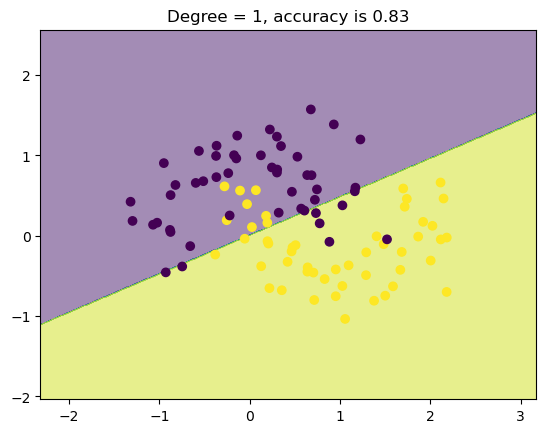

In [25]:
plot_decision_boundary(X,y)

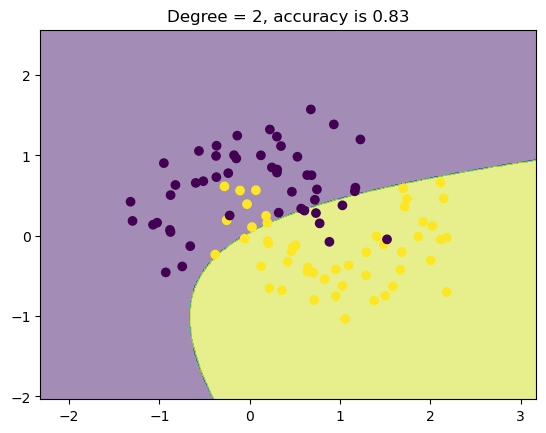

In [26]:
plot_decision_boundary(X,y,degree=2)

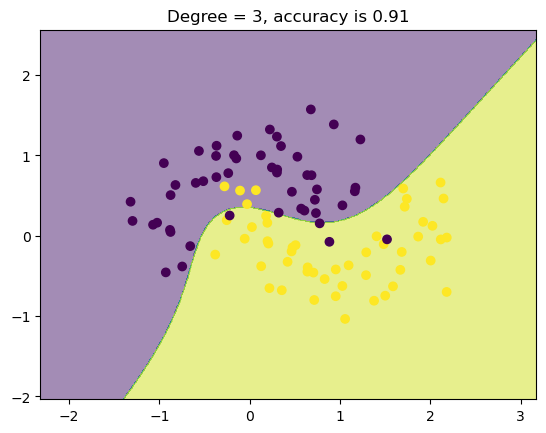

In [27]:
plot_decision_boundary(X,y,degree=3)

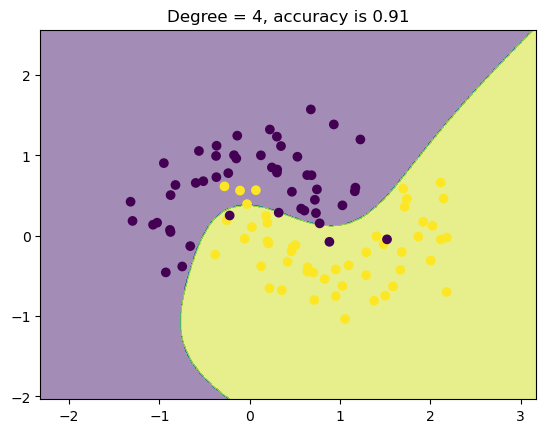

In [28]:
plot_decision_boundary(X,y,degree=4)

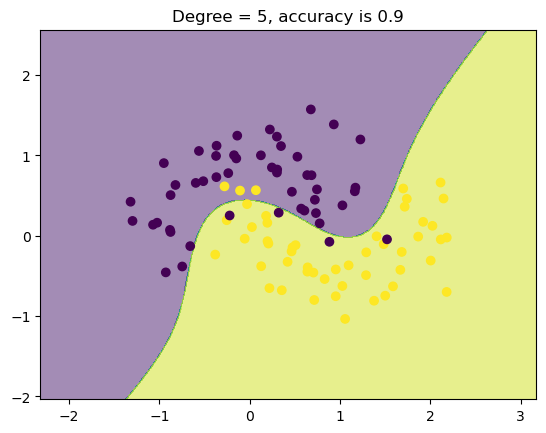

In [29]:
plot_decision_boundary(X,y,degree=5)

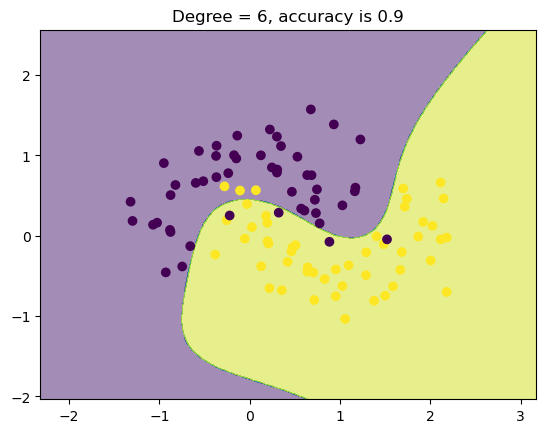

In [30]:
plot_decision_boundary(X,y,degree=6)

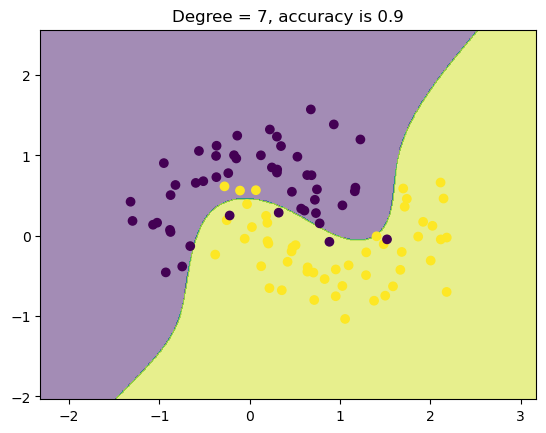

In [31]:
plot_decision_boundary(X,y,degree=7)

c:\Users\Sanjog Bhalla\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Sanjog Bhalla\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regr

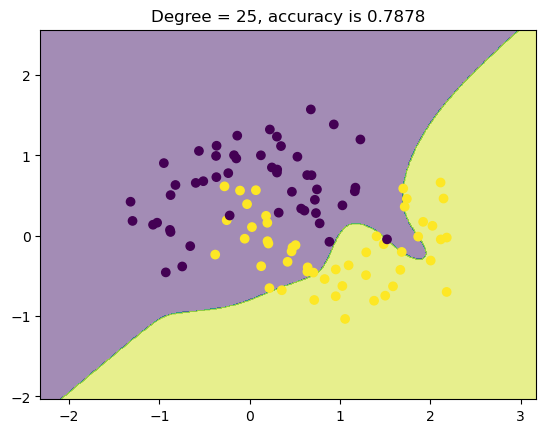

In [32]:
plot_decision_boundary(X,y,degree=25)